# __Phytoplankton Data Exploration__

### Objective:
Explore environmental dataset to understand structure and trends.

### _Part 1: Data Standardization_

##### Import pandas library

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Import data

Dataset: https://doi.org/10.5061/dryad.4fp90

In [96]:
df = pd.read_csv('Chla.csv')

# Check column names
print(df.columns)

Index(['Park', 'Lake_Code', 'Lake', 'Sample_Date', 'Treatment',
       'Treatment_N_ug', 'Treatment_P_ug', 'Treatment_Category', 'chl_a_ugL'],
      dtype='object')


##### Rename columns to standard names

In [97]:
# 2. Rename columns to standard names
df = df.rename(columns={
    'Sample_Date': 'date',
    'chl_a_ugL': 'chl',
    'Treatment_Category': 'treatment'})

##### Convert date to datetime objects

In [98]:
df['date'] = pd.to_datetime(df['date'])

/var/folders/qx/80c0mf493vgbyg1jj1g57cqw0000gn/T/ipykernel_29238/3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


##### Numeric Cleaning
(Replace any common "null" placeholders and drop rows without data)

In [99]:
df['chl'] = pd.to_numeric(df['chl'], errors='coerce') 
df = df.dropna(subset=['chl'])

### _Part 2: Exploratory Analysis_

##### Change treatment names for plotting and analysis

In [106]:
treatment_map = {
    'N + 31 ug P + 2.8 mg Si': 'N + P + Si',
    'N only': 'N Only',
    'P only': 'P Only',
    'no enrichment': 'No enrichment',
    '112 ug N + 31 ug P' : 'N + P'}

# Apply the transformation
df['treatment'] = df['treatment'].replace(treatment_map)

# Check the results
print(df['treatment'].value_counts())

treatment
N + P + Si       153
No enrichment     54
N + P             27
N Only            27
P Only            27
Name: count, dtype: int64


##### Summary Statistics

In [107]:
# Replace 'treatment' and 'chlorophyll' with your actual column names
summary_stats = df.groupby('treatment')['chl'].agg(['mean', 'std', 'count', 'median'])

# Sort by mean to see the most 'productive' treatment at the top
summary_stats = summary_stats.sort_values(by='mean', ascending=False)

print(summary_stats)

                   mean       std  count  median
treatment                                       
N + P          1.697037  1.665706     27    0.92
N Only         0.405185  0.361858     27    0.25
No enrichment  0.269630  0.223800     54    0.21
N + P + Si     0.233987  0.273169    153    0.13
P Only         0.162593  0.137410     27    0.11


##### Figure 1: Correlation Analysis

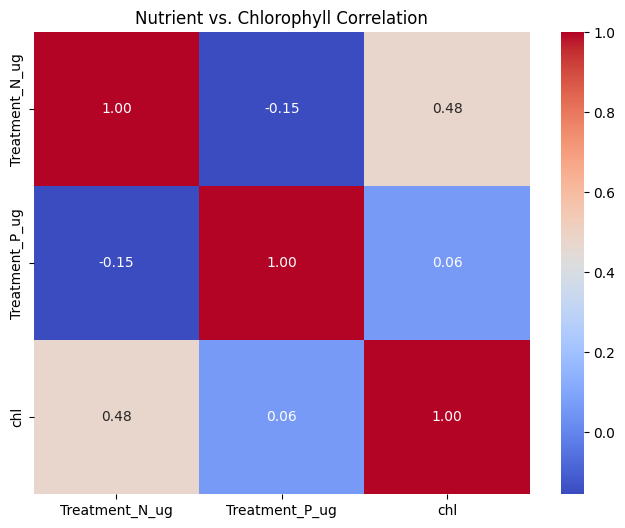

In [108]:
# Numeric columns for correlation
numeric_cols = ['Treatment_N_ug', 'Treatment_P_ug', 'chl']
correlation_matrix = df[numeric_cols].corr()

# Visualize with Heatmap
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Nutrient vs. Chlorophyll Correlation')
plt.show()

##### Figure 2: Time-Series Graph

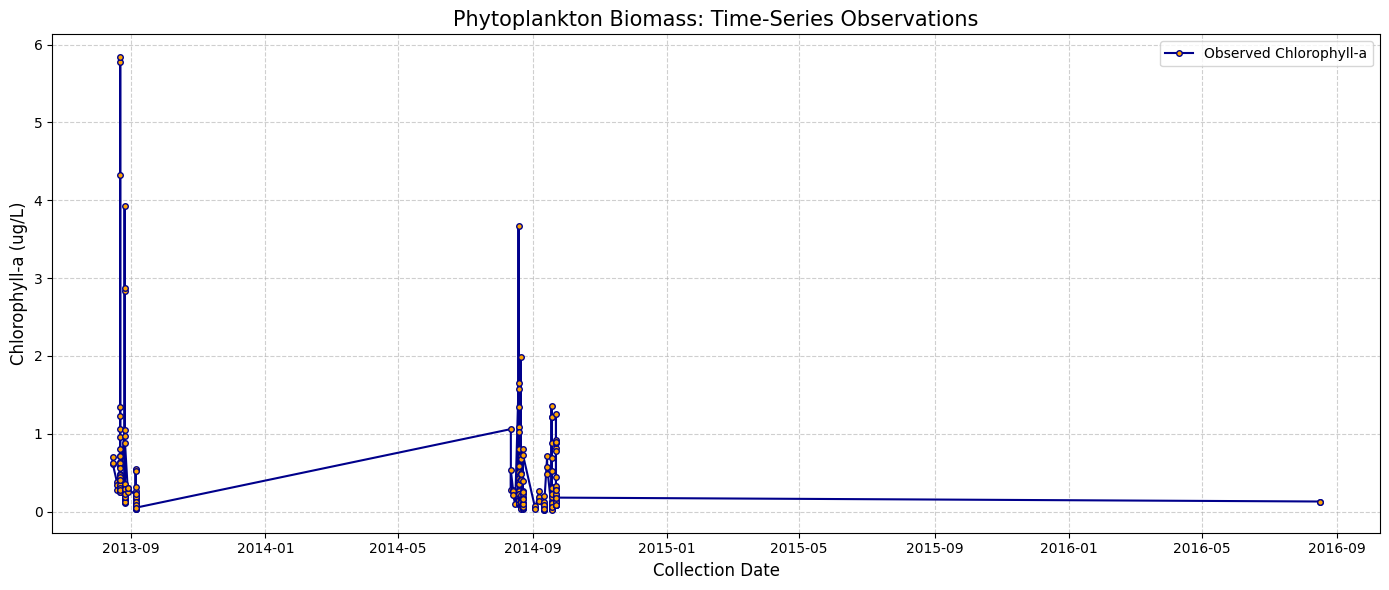

In [109]:
# Sorting by index is crucial so the lines don't 'criss-cross' randomly
df_time = df.set_index('date').sort_index()

# 2. Plotting the Raw Trend
plt.figure(figsize=(14, 6))

# We use marker='o' to highlight exactly when samples were taken
# The line connects them, but gaps will remain visible if there are missing dates
plt.plot(df_time.index, df_time['chl'], 
         color='darkblue', 
         linewidth=1.5, 
         marker='o', 
         markersize=4, 
         markerfacecolor='orange',
         label='Observed Chlorophyll-a')

# Formatting for a professional 'Marine Science' look
plt.title('Phytoplankton Biomass: Time-Series Observations', fontsize=15)
plt.ylabel('Chlorophyll-a (ug/L)', fontsize=12)
plt.xlabel('Collection Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Tighten layout to prevent clipping of labels
plt.tight_layout()
plt.show()

##### Figure 3: Yearly Average Bar Graph

/var/folders/qx/80c0mf493vgbyg1jj1g57cqw0000gn/T/ipykernel_29238/1290234281.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_avg, x='Year', y='chl', palette='Blues_d')


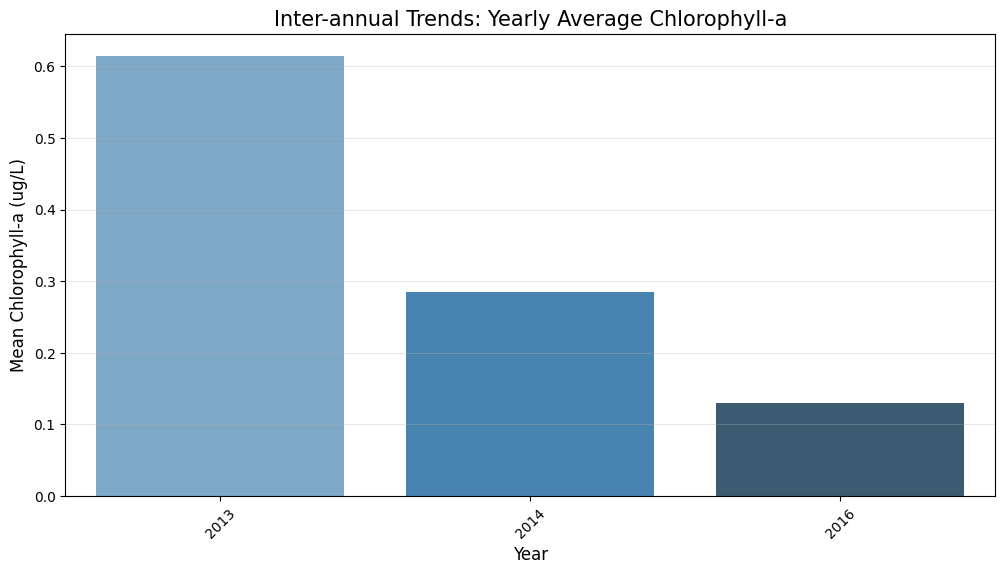

In [110]:

# (If you haven't renamed Sample_Date to date, use df['Sample_Date'])
df['Year'] = pd.to_datetime(df['date']).dt.year

# 2. Calculate Yearly Averages
yearly_avg = df.groupby('Year')['chl'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))

# Use a bar plot to show the comparison between years
sns.barplot(data=yearly_avg, x='Year', y='chl', palette='Blues_d')

# Professional touches
plt.title('Inter-annual Trends: Yearly Average Chlorophyll-a', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Chlorophyll-a (ug/L)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Ensure x-axis labels don't overlap if you have many years
plt.xticks(rotation=45)

plt.show()

##### Figure 4: Boxplot by Treatment

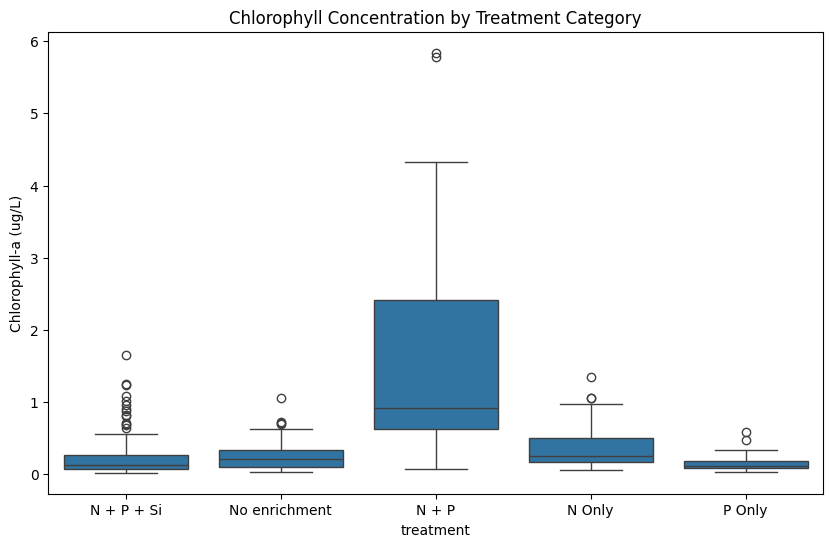

In [111]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='treatment', y='chl')
plt.title('Chlorophyll Concentration by Treatment Category')
plt.ylabel('Chlorophyll-a (ug/L)')
plt.show()